# 03 — Teukolsky Amplitude Interpolation

This notebook covers `fewtrax.amplitude` and `fewtrax.data.loader`.

**Topics:**
- The FEW precomputed amplitude data (`ZNAmps_l10_m10_n55_DS2Outer.h5`)
- The $(a, p, e)$ → $(u, w, z)$ coordinate compression (Regions A and B)
- Mode ordering (FEW's `m0sort`)
- Evaluating $A_{\ell m k n}$ along a trajectory
- Mode selection by relative power

---

## Background: Teukolsky Amplitudes

The gravitational-wave emission from an EMRI is decomposed into **Teukolsky modes** $Z^\infty_{\ell m k n}(a, p, e)$.  For the KerrEccentricEquatorial model these are parameterised by four integers $(\ell, m, k, n)$:
- $\ell, m$: angular harmonic numbers ($\ell \ge 2$, $|m| \le \ell$)
- $k$: polar harmonic number (always $k = 0$ for equatorial orbits)
- $n$: radial harmonic number ($n \in [-55, 55]$ for the FEW grid)

The dominant modes are typically $(2, 2, 0, n)$ for small $n$.  The FEW amplitude file stores bicubic B-spline coefficients for all $6{,}993$ modes in a compressed coordinate system.

### Compressed Coordinates

The physical domain $(a, p, e)$ is mapped to the unit cube $[0,1]^3$ via:

| Coordinate | Physical | Compressed |
|---|---|---|
| $u$ | $p$ (near separatrix) | $u = \left[\log_2\left(1 + \frac{p - p_{\rm sep}}{\Delta p_{\rm max}}\right)\right]^{1/3}$ |
| $w$ | $e$ | $w = e / S_{\rm ecc}(u, z)$ |
| $z$ | $a$ | $z = (\chi(a) - \chi_{\rm min}) / (\chi_{\rm max} - \chi_{\rm min})$, $\chi = (1-a)^{1/3}$ |

Two regions are defined:
- **Region A** ($p \le p_{\rm sep} + \Delta p_{\rm max}$): near-separatrix, parametrised by $(u, w, z)$ with $\alpha = 1/3$
- **Region B** ($p > p_{\rm sep} + \Delta p_{\rm max}$): far region, different compression

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")

from fewtrax.data import load_amplitude_data, load_flux_data
from fewtrax.amplitude import AmplitudeInterpolator

print("Loading amplitude data (may take a moment)…")
amp_data = load_amplitude_data(DATA_DIR)
amp = AmplitudeInterpolator(amp_data)
print(f"Loaded {amp.n_modes} modes.")

FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data
Loading amplitude data (may take a moment)…
Loaded 6993 modes.


## 3.1  Mode Index Arrays

The modes are ordered in FEW's `m0sort` convention: all $m=0$ modes come first (sorted by $\ell$ then $n$), followed by $m \ne 0$ modes in the standard enumeration order.  This ordering matches the rows of the HDF5 coefficient array.

In [2]:
l_arr = amp.l_arr
m_arr = amp.m_arr
n_arr = amp.n_arr

print("First 10 modes (m=0 group):")
for i in range(10):
    print(f"  [{i:4d}]  l={l_arr[i]:2d}  m={m_arr[i]:2d}  k=0  n={n_arr[i]:3d}")

# Count m=0 modes
n_m0 = int(np.sum(m_arr == 0))
print(f"\nTotal m=0 modes: {n_m0}")

print("\nFirst 5 m≠0 modes:")
nonzero = np.where(m_arr != 0)[0][:5]
for i in nonzero:
    print(f"  [{i:4d}]  l={l_arr[i]:2d}  m={m_arr[i]:2d}  k=0  n={n_arr[i]:3d}")

First 10 modes (m=0 group):
  [   0]  l= 2  m= 0  k=0  n=-55
  [   1]  l= 2  m= 0  k=0  n=-54
  [   2]  l= 2  m= 0  k=0  n=-53
  [   3]  l= 2  m= 0  k=0  n=-52
  [   4]  l= 2  m= 0  k=0  n=-51
  [   5]  l= 2  m= 0  k=0  n=-50
  [   6]  l= 2  m= 0  k=0  n=-49
  [   7]  l= 2  m= 0  k=0  n=-48
  [   8]  l= 2  m= 0  k=0  n=-47
  [   9]  l= 2  m= 0  k=0  n=-46

Total m=0 modes: 999

First 5 m≠0 modes:
  [ 999]  l= 2  m= 1  k=0  n=-55
  [1000]  l= 2  m= 1  k=0  n=-54
  [1001]  l= 2  m= 1  k=0  n=-53
  [1002]  l= 2  m= 1  k=0  n=-52
  [1003]  l= 2  m= 1  k=0  n=-51


## 3.2  Coordinate Mapping Visualisation

Let's see how a range of $(p, e)$ values map into the $(u, w)$ compressed space.

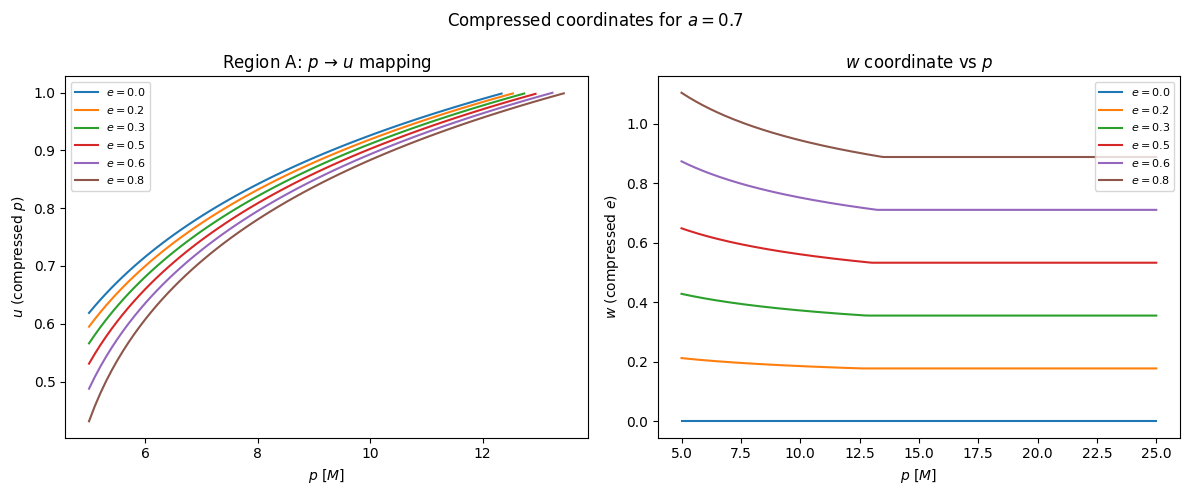

In [3]:
from fewtrax.utils.coordinates import kerrecceq_forward_map
from fewtrax.utils.geodesic import get_separatrix

a = 0.7

# Build a grid of (p, e) values and compute (u, w)
e_vals = np.linspace(0.0, 0.8, 6)
p_vals = np.linspace(5, 25, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for e_val in e_vals:
    u_arr, w_arr, z_arr, in_A = zip(*[
        kerrecceq_forward_map(a, p, e_val, kind="amplitude")
        for p in p_vals
    ])
    u_arr = np.array([float(x) for x in u_arr])
    w_arr = np.array([float(x) for x in w_arr])

    # Region A portion
    in_A_np = np.array([bool(x) for x in in_A])
    axes[0].plot(p_vals[in_A_np], u_arr[in_A_np], label=f"$e={e_val:.1f}$")
    axes[1].plot(p_vals, w_arr, label=f"$e={e_val:.1f}$")

axes[0].set_xlabel("$p$ [$M$]")
axes[0].set_ylabel("$u$ (compressed $p$)")
axes[0].set_title("Region A: $p$ → $u$ mapping")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("$p$ [$M$]")
axes[1].set_ylabel("$w$ (compressed $e$)")
axes[1].set_title("$w$ coordinate vs $p$")
axes[1].legend(fontsize=8)

plt.suptitle(f"Compressed coordinates for $a = {a}$")
plt.tight_layout()
plt.show()

## 3.3  Evaluating Amplitudes Along a Trajectory

`AmplitudeInterpolator.evaluate(a, p, e)` returns an array of shape `(N_traj, N_modes)` of complex amplitudes.  The evaluation uses scipy's `bisplev` with the FEW B-spline coefficients, linearly interpolating between adjacent spin slices.

In [4]:
from fewtrax.trajectory import run_inspiral

flux_data = load_flux_data(DATA_DIR)

# Get a trajectory
a = 0.7
t, p, e, *_ = run_inspiral(
    a=a, p0=12.0, e0=0.4, T=1.0,
    flux_data=flux_data, M=1e6, mu=10.0, dense_steps=50,
)
p_np = np.asarray(p)
e_np = np.asarray(e)
valid = ~np.isnan(p_np)
p_np, e_np = p_np[valid], e_np[valid]

print(f"Evaluating amplitudes for {valid.sum()} trajectory points…")
amps = amp.evaluate(a=a, p=p_np, e=e_np)
print(f"Amplitude array shape: {amps.shape}  (N_traj × N_modes)")

Evaluating amplitudes for 50 trajectory points…
Amplitude array shape: (50, 6993)  (N_traj × N_modes)


In [5]:
# Compute power |A|^2 for each mode, averaged over trajectory
power = np.mean(np.abs(amps)**2, axis=0)
total_power = power.sum()

# Sort by power
order = np.argsort(power)[::-1]

print("Top 10 modes by mean power:")
print(f"{'Rank':>4}  {'Index':>6}  {'(l,m,n)':>12}  {'Frac. power':>12}")
print("-" * 40)
for rank, idx in enumerate(order[:10]):
    lmn = f"({l_arr[idx]},{m_arr[idx]},{n_arr[idx]})"
    print(f"{rank+1:4d}  {idx:6d}  {lmn:>12}  {power[idx]/total_power:12.4%}")

Top 10 modes by mean power:
Rank   Index       (l,m,n)   Frac. power
----------------------------------------
   1    1166       (2,2,1)      30.8809%
   2    1165       (2,2,0)      20.2686%
   3    1167       (2,2,2)      17.6716%
   4    1164      (2,2,-1)      14.6029%
   5    1168       (2,2,3)       7.1191%
   6    1169       (2,2,4)       2.3836%
   7    1500       (3,3,2)       1.1570%
   8    1501       (3,3,3)       0.9293%
   9    1497      (3,3,-1)       0.7198%
  10    1170       (2,2,5)       0.7110%


## 3.4  Mode Selection by Power Threshold

`select_modes` returns the indices of modes whose mean power exceeds a fraction `threshold` of the dominant mode's power.  This is a crucial step for efficiency: several hundreds of modes out of 6993 capture >99% of the power.

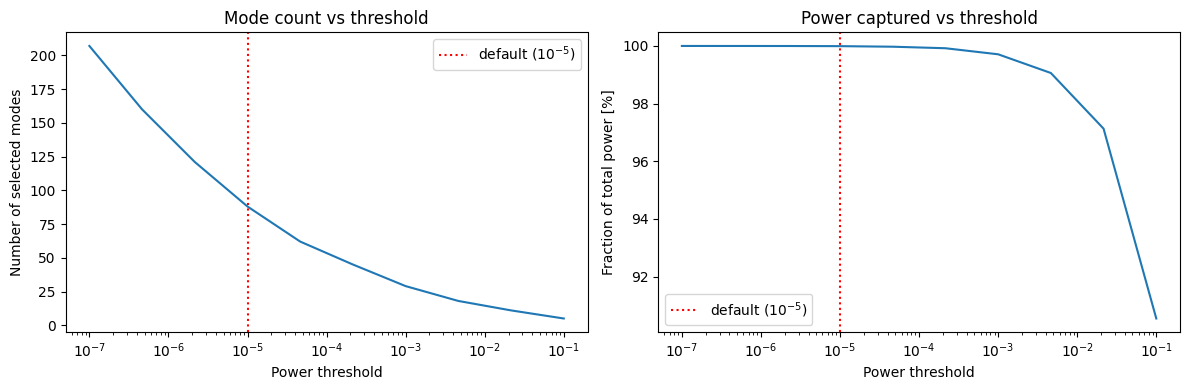


Default threshold 1e-5: 88 modes, 99.99331% of total power


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

thresholds = np.logspace(-7, -1, 10)
n_modes_selected = []
frac_power = []

for thr in thresholds:
    sel = amp.select_modes(a, p_np, e_np, threshold=thr)
    n_modes_selected.append(len(sel))
    frac_power.append(power[sel].sum() / total_power)

axes[0].semilogx(thresholds, n_modes_selected)
axes[0].set_xlabel("Power threshold")
axes[0].set_ylabel("Number of selected modes")
axes[0].set_title("Mode count vs threshold")
axes[0].axvline(1e-5, color="r", linestyle=":", label="default ($10^{-5}$)")
axes[0].legend()

axes[1].semilogx(thresholds, np.array(frac_power) * 100)
axes[1].set_xlabel("Power threshold")
axes[1].set_ylabel("Fraction of total power [%]")
axes[1].set_title("Power captured vs threshold")
axes[1].axvline(1e-5, color="r", linestyle=":", label="default ($10^{-5}$)")
axes[1].legend()

plt.tight_layout()
plt.show()

sel = amp.select_modes(a, p_np, e_np, threshold=1e-5)
print(f"\nDefault threshold 1e-5: {len(sel)} modes, {power[sel].sum()/total_power:.5%} of total power")

## 3.5  Amplitude Time Evolution

As the orbit inspirals, the amplitudes change.  The dominant $(2,2,0,1)$ mode grows as $p$ decreases.

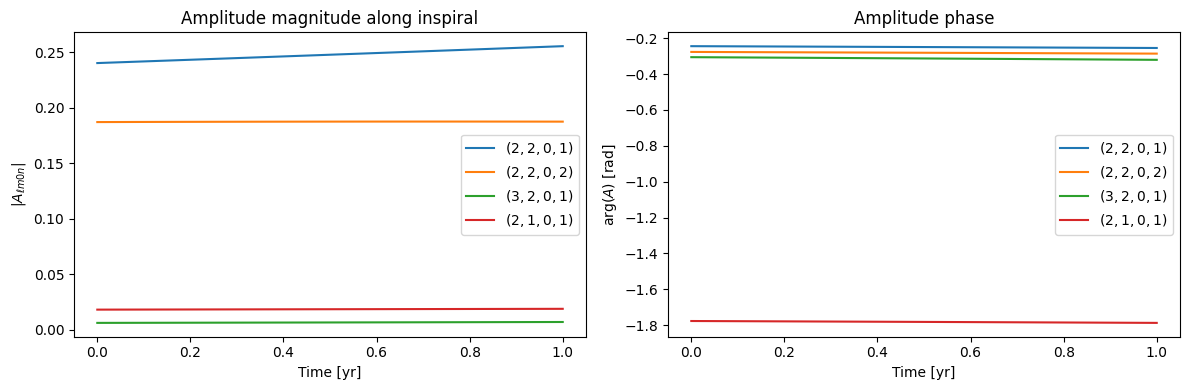

In [8]:
# Find a few specific modes
def find_mode(l, m, n):
    for i in range(len(l_arr)):
        if l_arr[i] == l and m_arr[i] == m and n_arr[i] == n:
            return i
    return None

modes_to_show = [(2, 2, 1), (2, 2, 2), (3, 2, 1), (2, 1, 1)]
t_yr_valid = np.asarray(t)[valid] / (365.25 * 24 * 3600)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (l, m, n) in modes_to_show:
    idx = find_mode(l, m, n)
    if idx is None:
        print(f"Mode ({l},{m},0,{n}) not found")
        continue
    A = amps[:, idx]
    axes[0].plot(t_yr_valid, np.abs(A), label=f"$({l},{m},0,{n})$")
    axes[1].plot(t_yr_valid, np.angle(A), label=f"$({l},{m},0,{n})$")

axes[0].set_xlabel("Time [yr]")
axes[0].set_ylabel("$|A_{\\ell m 0 n}|$")
axes[0].set_title("Amplitude magnitude along inspiral")
axes[0].legend()

axes[1].set_xlabel("Time [yr]")
axes[1].set_ylabel(r"$\arg(A)$ [rad]")
axes[1].set_title("Amplitude phase")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.6  Spin Dependence of the Dominant Mode

Let's see how the amplitude of the $(2,2,0,1)$ mode varies with spin $a$ at a fixed orbital point.

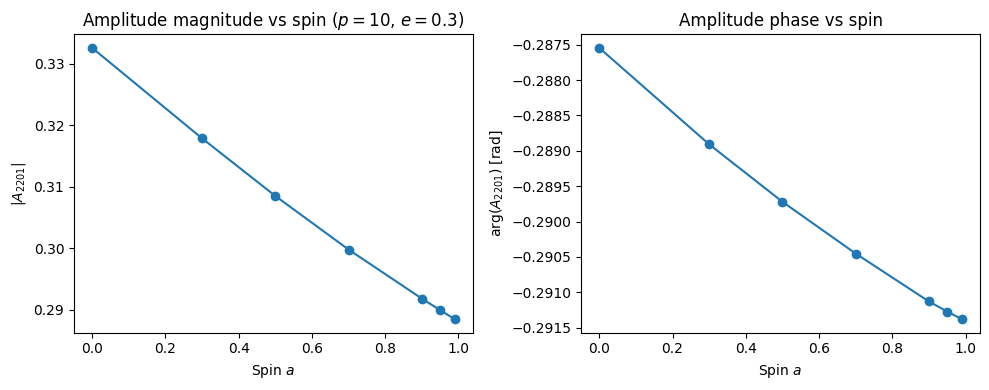

In [9]:
idx_221 = find_mode(2, 2, 1)

a_vals = np.array([0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99])
p_fixed = np.array([10.0])
e_fixed = np.array([0.3])

A_vals = []
for a_v in a_vals:
    A = amp.evaluate(a=a_v, p=p_fixed, e=e_fixed, specific_modes=np.array([idx_221]))
    A_vals.append(complex(A[0, 0]))

A_vals = np.array(A_vals)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(a_vals, np.abs(A_vals), "o-")
axes[0].set_xlabel("Spin $a$")
axes[0].set_ylabel("$|A_{2201}|$")
axes[0].set_title("Amplitude magnitude vs spin ($p=10$, $e=0.3$)")

axes[1].plot(a_vals, np.angle(A_vals), "o-")
axes[1].set_xlabel("Spin $a$")
axes[1].set_ylabel(r"$\arg(A_{2201})$ [rad]")
axes[1].set_title("Amplitude phase vs spin")

plt.tight_layout()
plt.show()

## Summary

| Component | Description |
|---|---|
| `load_amplitude_data(data_dir)` | Reads the HDF5 file, returns `AmplitudeData` container |
| `AmplitudeInterpolator(amp_data)` | Wraps the data for evaluation |
| `.evaluate(a, p, e)` | Returns `(N_traj, N_modes)` complex amplitudes via `bisplev` + linear $z$-interpolation |
| `.select_modes(a, p, e, threshold)` | Returns indices of modes above power threshold |
| Mode ordering | FEW `m0sort`: $m=0$ first, then $m \ne 0$ in standard order |
| Coefficient axes | `bisplev(w, u, (w_knots, u_knots, c, 3, 3))` — $w$ is first axis |

**Next:** [04_mode_summation.ipynb](04_mode_summation.ipynb) — summing the harmonic modes to produce $h_+$ and $h_\times$.